# Proyecto 3 — Optimización de Pricing en Rutas de Ferry

## Notebook 4 — Modelo predictivo de demanda

En este notebook construimos modelos de Machine Learning para predecir la demanda de pasajeros en rutas de ferry de la compañía ficticia **Levante Ferries**.

El objetivo es estimar cuántos tickets se venderán para cada viaje a partir de variables comerciales, temporales y operativas.

Este notebook conecta directamente con los anteriores:

- Notebook 1: generación del dataset.
- Notebook 2: análisis exploratorio de pricing y demanda.
- Notebook 3: elasticidad precio-demanda y simulación de escenarios.
- Notebook 4: predicción de demanda para alimentar decisiones de pricing.

## 1. Objetivo del notebook

El objetivo es construir un modelo capaz de predecir `tickets_sold`.

La predicción de demanda es clave para pricing porque permite responder preguntas como:

- ¿Cuánta demanda esperamos para una ruta concreta?
- ¿Qué viajes tienen riesgo de baja ocupación?
- ¿Qué viajes pueden saturarse?
- ¿Qué variables explican mejor la demanda?
- ¿Qué rutas o temporadas tienen mayor error de predicción?
- ¿Qué modelo ofrece mejor equilibrio entre precisión e interpretabilidad?

En este notebook entrenaremos varios modelos:

1. Baseline simple.
2. Regresión lineal.
3. Ridge Regression.
4. Random Forest.
5. Gradient Boosting.

Después compararemos métricas y elegiremos el mejor modelo para usarlo en los siguientes notebooks.

In [1]:
# ============================================================
# 1. IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os
import warnings
import joblib

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from openpyxl.styles import Font
from openpyxl.utils import get_column_letter

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Librerías importadas correctamente.")

Librerías importadas correctamente.


In [2]:
# ============================================================
# 2. CONEXIÓN CON GOOGLE DRIVE
# ============================================================

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("Google Drive conectado correctamente.")
except:
    print("No estás ejecutando este notebook en Google Colab o Drive ya está montado.")

Mounted at /content/drive
Google Drive conectado correctamente.


In [3]:
# ============================================================
# 3. DEFINICIÓN DE RUTAS DEL PROYECTO
# ============================================================

base_path = "/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing"

data_path = f"{base_path}/data/processed/ferry_pricing_dataset.csv"
reports_path = f"{base_path}/reports"
images_path = f"{base_path}/images"
models_path = f"{base_path}/models"

os.makedirs(reports_path, exist_ok=True)
os.makedirs(images_path, exist_ok=True)
os.makedirs(models_path, exist_ok=True)

print("Ruta base del proyecto:")
print(base_path)

print("\nRuta del dataset:")
print(data_path)

Ruta base del proyecto:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing

Ruta del dataset:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/data/processed/ferry_pricing_dataset.csv


## 2. Funciones auxiliares

Creamos funciones para:

- Asegurar columnas numéricas.
- Exportar tablas en CSV estándar, CSV Excel España y XLSX.
- Calcular métricas de modelos.
- Evaluar errores por segmentos.
- Extraer importancia de variables.

In [4]:
# ============================================================
# 4. FUNCIÓN AUXILIAR: ASEGURAR COLUMNAS NUMÉRICAS
# ============================================================

def force_numeric_columns(dataframe, columns):
    """
    Convierte columnas a formato numérico aunque vengan como texto.
    Soporta formatos como:
    - 1234.56
    - 1234,56
    - 1.234,56 €
    - 45,5 %
    """

    df_copy = dataframe.copy()

    for col in columns:
        if col not in df_copy.columns:
            continue

        direct_conversion = pd.to_numeric(df_copy[col], errors="coerce")

        if direct_conversion.notna().mean() >= 0.80:
            df_copy[col] = direct_conversion
        else:
            df_copy[col] = (
                df_copy[col]
                .astype(str)
                .str.replace("€", "", regex=False)
                .str.replace("%", "", regex=False)
                .str.replace(" ", "", regex=False)
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )

            df_copy[col] = pd.to_numeric(df_copy[col], errors="coerce")

    return df_copy


print("Función force_numeric_columns creada correctamente.")

Función force_numeric_columns creada correctamente.


In [5]:
# ============================================================
# 5. FUNCIÓN DE EXPORTACIÓN: CSV NORMAL + CSV EXCEL ES + XLSX
# ============================================================

def export_table_files(dataframe, output_folder, file_name, sheet_name="Data"):
    """
    Exporta un DataFrame en tres formatos:

    1. CSV estándar para Python.
    2. CSV compatible con Excel España: separador ; y decimal ,
    3. XLSX con formato numérico.
    """

    os.makedirs(output_folder, exist_ok=True)

    csv_path = f"{output_folder}/{file_name}.csv"
    csv_excel_es_path = f"{output_folder}/{file_name}_excel_es.csv"
    xlsx_path = f"{output_folder}/{file_name}.xlsx"

    df_export = dataframe.copy()

    for col in df_export.columns:
        if pd.api.types.is_datetime64_any_dtype(df_export[col]):
            df_export[col] = df_export[col].dt.strftime("%d/%m/%Y %H:%M")

    dataframe.to_csv(csv_path, index=False, encoding="utf-8-sig")

    df_export.to_csv(
        csv_excel_es_path,
        index=False,
        sep=";",
        decimal=",",
        encoding="utf-8-sig"
    )

    safe_sheet_name = sheet_name[:31]

    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        dataframe.to_excel(writer, index=False, sheet_name=safe_sheet_name)

        worksheet = writer.sheets[safe_sheet_name]
        worksheet.freeze_panes = "A2"
        worksheet.auto_filter.ref = worksheet.dimensions

        for cell in worksheet[1]:
            cell.font = Font(bold=True)

        for col_idx, col_name in enumerate(dataframe.columns, start=1):
            column_letter = get_column_letter(col_idx)

            if pd.api.types.is_float_dtype(dataframe[col_name]):
                if col_name in [
                    "occupancy_rate",
                    "avg_occupancy",
                    "margin_pct",
                    "avg_margin_pct",
                    "mape",
                    "mean_absolute_percentage_error",
                    "error_pct",
                    "prediction_error_pct"
                ]:
                    number_format = "0.00%"
                else:
                    number_format = "0.00"

                for cell in worksheet[column_letter][1:]:
                    cell.number_format = number_format

            elif pd.api.types.is_integer_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "0"

            elif pd.api.types.is_datetime64_any_dtype(dataframe[col_name]):
                for cell in worksheet[column_letter][1:]:
                    cell.number_format = "DD/MM/YYYY HH:MM"

        for column_cells in worksheet.columns:
            max_length = 0
            column_letter = get_column_letter(column_cells[0].column)

            for cell in column_cells:
                if cell.value is not None:
                    max_length = max(max_length, len(str(cell.value)))

            adjusted_width = min(max_length + 2, 40)
            worksheet.column_dimensions[column_letter].width = adjusted_width

    print(f"Exportado: {file_name}")


print("Función export_table_files creada correctamente.")

Función export_table_files creada correctamente.


In [6]:
# ============================================================
# 6. FUNCIONES DE EVALUACIÓN DE MODELOS
# ============================================================

def mean_absolute_percentage_error_safe(y_true, y_pred):
    """
    Calcula MAPE evitando divisiones entre cero.
    """

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    mask = y_true != 0

    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))


def evaluate_regression_model(model_name, y_true, y_pred):
    """
    Calcula métricas de regresión.
    """

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error_safe(y_true, y_pred)

    return {
        "model": model_name,
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "mape": mape
    }


def clip_predictions_to_capacity(predictions, capacity):
    """
    Limita las predicciones entre 0 y la capacidad del ferry.
    """

    clipped = np.maximum(predictions, 0)
    clipped = np.minimum(clipped, capacity)

    return clipped


def classify_prediction_error(abs_error):
    """
    Clasifica el error absoluto en buckets interpretables.
    """

    if abs_error <= 10:
        return "Very low error"
    elif abs_error <= 25:
        return "Low error"
    elif abs_error <= 50:
        return "Medium error"
    else:
        return "High error"


print("Funciones de evaluación creadas correctamente.")

Funciones de evaluación creadas correctamente.


## 3. Carga y revisión del dataset

Cargamos el dataset final generado en el Notebook 1.

La variable objetivo del modelo será:

`tickets_sold`

No usaremos variables que impliquen fuga de información, como:

- `revenue`
- `margin`
- `occupancy_rate`
- `total_operational_cost`
- `demand_level`
- `pricing_opportunity`

Estas columnas se calculan después de conocer los tickets vendidos, por lo que no deben alimentar el modelo predictivo.

In [7]:
# ============================================================
# 7. CARGA DEL DATASET
# ============================================================

df = pd.read_csv(data_path, parse_dates=["trip_date", "departure_datetime"])

print("Dataset cargado correctamente.")
print(f"Filas: {df.shape[0]:,}")
print(f"Columnas: {df.shape[1]:,}")

df.head()

Dataset cargado correctamente.
Filas: 5,475
Columnas: 38


,trip_id,trip_date,departure_datetime,year,month,week,day_of_week,is_weekend,season,high_season_flag,route,origin,destination,route_type,vessel_type,departure_hour,capacity,base_price,avg_ticket_price,competitor_price,price_index_vs_competitor,route_elasticity,days_before_departure,booking_window,weather_score,event_flag,expected_demand,tickets_sold,occupancy_rate,revenue,fixed_operational_cost,variable_cost_per_passenger,total_operational_cost,margin,margin_pct,demand_level,pricing_opportunity,trip_feature
0,TRIP_000001,2025-01-01,2025-01-01 08:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,8,350,58,44.7600,42.0200,1.0650,-0.8500,50,Early,7.9000,0,189,189,0.5400,"8,459.6400",14500,8,16012,"-7,552.3600",-0.8928,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Early
1,TRIP_000002,2025-01-01,2025-01-01 14:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,14,350,58,57.3500,57.2600,1.0020,-0.8500,34,Medium,7.0000,0,160,160,0.4571,"9,176.0000",14500,8,15780,"-6,604.0000",-0.7197,Low,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Medium
2,TRIP_000003,2025-01-01,2025-01-01 20:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Ibiza,Denia,Ibiza,Inter-island / Mainland-Island,Fast Ferry,20,350,58,56.7800,62.5200,0.9080,-0.8500,9,Short,8.1000,0,195,195,0.5571,"11,072.1000",14500,8,16060,"-4,987.9000",-0.4505,Medium,Maintain / Monitor,Denia-Ibiza | Low | Wednesday | Short
3,TRIP_000004,2025-01-01,2025-01-01 09:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,9,280,72,66.9300,66.9800,0.9990,-0.7500,24,Medium,9.3000,0,160,160,0.5714,"10,708.8000",13200,7,14320,"-3,611.2000",-0.3372,Medium,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium
4,TRIP_000005,2025-01-01,2025-01-01 17:00:00,2025,1,1,Wednesday,0,Low,0,Denia-Formentera,Denia,Formentera,Mainland-Island,Fast Ferry,17,280,72,64.1600,63.4100,1.0120,-0.7500,36,Medium,6.9000,0,131,131,0.4679,"8,404.9600",13200,7,14117,"-5,712.0400",-0.6796,Low,Maintain / Monitor,Denia-Formentera | Low | Wednesday | Medium


In [8]:
# ============================================================
# 8. ASEGURAR TIPOS NUMÉRICOS
# ============================================================

numeric_columns_to_check = [
    "capacity",
    "base_price",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "route_elasticity",
    "days_before_departure",
    "weather_score",
    "event_flag",
    "expected_demand",
    "tickets_sold",
    "occupancy_rate",
    "revenue",
    "fixed_operational_cost",
    "variable_cost_per_passenger",
    "total_operational_cost",
    "margin",
    "margin_pct"
]

df = force_numeric_columns(df, numeric_columns_to_check)

print("Columnas numéricas revisadas correctamente.")
df[numeric_columns_to_check].dtypes

Columnas numéricas revisadas correctamente.


,0
capacity,int64
base_price,int64
avg_ticket_price,float64
competitor_price,float64
price_index_vs_competitor,float64
route_elasticity,float64
days_before_departure,int64
weather_score,float64
event_flag,int64
expected_demand,int64


In [9]:
# ============================================================
# 9. VALIDACIONES BÁSICAS
# ============================================================

print("Validación 1: tickets_sold nunca debe superar capacity")
print((df["tickets_sold"] <= df["capacity"]).all())

print("\nValidación 2: occupancy_rate entre 0 y 1")
print(df["occupancy_rate"].between(0, 1).all())

print("\nValidación 3: avg_ticket_price positivo")
print((df["avg_ticket_price"] > 0).all())

print("\nValidación 4: no debería haber nulos")
print(df.isnull().sum().sum() == 0)

print("\nValores nulos por columna:")
df.isnull().sum()[df.isnull().sum() > 0]

Validación 1: tickets_sold nunca debe superar capacity
True

Validación 2: occupancy_rate entre 0 y 1
True

Validación 3: avg_ticket_price positivo
True

Validación 4: no debería haber nulos
True

Valores nulos por columna:


,0


## 4. Selección de variable objetivo y variables predictoras

La variable objetivo será:

`tickets_sold`

Elegimos variables disponibles antes o durante la decisión de pricing:

- Variables temporales.
- Variables de ruta.
- Variables de capacidad.
- Variables de precio.
- Variables de antelación.
- Variables externas como clima o eventos.
- Precio frente al competidor.

Evitamos variables de fuga de información porque se calculan después de vender tickets.

In [10]:
# ============================================================
# 10. DEFINICIÓN DE TARGET Y FEATURES
# ============================================================

target = "tickets_sold"

numeric_features = [
    "month",
    "week",
    "departure_hour",
    "is_weekend",
    "high_season_flag",
    "capacity",
    "base_price",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "route_elasticity",
    "days_before_departure",
    "weather_score",
    "event_flag"
]

categorical_features = [
    "route",
    "origin",
    "destination",
    "route_type",
    "vessel_type",
    "day_of_week",
    "season",
    "booking_window"
]

feature_columns = numeric_features + categorical_features

X = df[feature_columns].copy()
y = df[target].copy()

print("Variable objetivo:")
print(target)

print("\nVariables numéricas:")
print(numeric_features)

print("\nVariables categóricas:")
print(categorical_features)

print(f"\nShape de X: {X.shape}")
print(f"Shape de y: {y.shape}")

Variable objetivo:
tickets_sold

Variables numéricas:
['month', 'week', 'departure_hour', 'is_weekend', 'high_season_flag', 'capacity', 'base_price', 'avg_ticket_price', 'competitor_price', 'price_index_vs_competitor', 'route_elasticity', 'days_before_departure', 'weather_score', 'event_flag']

Variables categóricas:
['route', 'origin', 'destination', 'route_type', 'vessel_type', 'day_of_week', 'season', 'booking_window']

Shape de X: (5475, 22)
Shape de y: (5475,)


## 5. División train/test

Usamos una división temporal:

- Train: meses 1 a 10.
- Test: meses 11 y 12.

Esto es más realista que una división aleatoria porque en negocio normalmente entrenamos con datos históricos y predecimos datos futuros.

Nota: en un caso real también podríamos usar validación temporal con varios cortes.

In [11]:
# ============================================================
# 11. DIVISIÓN TEMPORAL TRAIN / TEST
# ============================================================

train_mask = df["month"] <= 10
test_mask = df["month"] > 10

X_train = X.loc[train_mask].copy()
X_test = X.loc[test_mask].copy()

y_train = y.loc[train_mask].copy()
y_test = y.loc[test_mask].copy()

df_train = df.loc[train_mask].copy()
df_test = df.loc[test_mask].copy()

print("Train:")
print(f"Filas: {X_train.shape[0]:,}")
print(f"Meses: {sorted(df_train['month'].unique())}")

print("\nTest:")
print(f"Filas: {X_test.shape[0]:,}")
print(f"Meses: {sorted(df_test['month'].unique())}")

Train:
Filas: 4,560
Meses: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Test:
Filas: 915
Meses: [np.int64(11), np.int64(12)]


## 6. Pipeline de preprocesamiento

Creamos un pipeline para tratar variables numéricas y categóricas.

Variables numéricas:

- Imputación con mediana.
- Escalado estándar.

Variables categóricas:

- Imputación con valor más frecuente.
- One Hot Encoding.

Esto nos permite entrenar todos los modelos de forma consistente.

In [12]:
# ============================================================
# 12. PREPROCESAMIENTO
# ============================================================

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocesamiento definido correctamente.")

Preprocesamiento definido correctamente.


## 7. Definición de modelos

Entrenaremos una batería de modelos para comparar rendimiento.

El baseline es imprescindible porque nos dice si los modelos realmente aportan valor.

In [13]:
# ============================================================
# 13. DEFINICIÓN DE MODELOS
# ============================================================

models = {
    "Baseline_Mean": DummyRegressor(strategy="mean"),
    "Linear_Regression": LinearRegression(),
    "Ridge_Regression": Ridge(alpha=1.0, random_state=42),
    "Random_Forest": RandomForestRegressor(
        n_estimators=250,
        max_depth=14,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ),
    "Gradient_Boosting": GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )
}

print("Modelos definidos:")
for model_name in models.keys():
    print("-", model_name)

Modelos definidos:
- Baseline_Mean
- Linear_Regression
- Ridge_Regression
- Random_Forest
- Gradient_Boosting


## 8. Entrenamiento y evaluación de modelos

Entrenamos cada modelo dentro de un pipeline completo:

`preprocesamiento + modelo`

Después evaluamos:

- MAE: error medio absoluto en pasajeros.
- RMSE: penaliza más los errores grandes.
- R²: capacidad explicativa del modelo.
- MAPE: error porcentual medio.

Además, limitamos las predicciones entre 0 y la capacidad del ferry.

In [14]:
# ============================================================
# 14. ENTRENAMIENTO Y EVALUACIÓN
# ============================================================

trained_pipelines = {}
model_results = []

for model_name, model in models.items():

    print(f"Entrenando modelo: {model_name}")

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", model)
        ]
    )

    pipeline.fit(X_train, y_train)

    raw_predictions = pipeline.predict(X_test)
    clipped_predictions = clip_predictions_to_capacity(
        predictions=raw_predictions,
        capacity=df_test["capacity"].values
    )

    metrics = evaluate_regression_model(
        model_name=model_name,
        y_true=y_test,
        y_pred=clipped_predictions
    )

    model_results.append(metrics)
    trained_pipelines[model_name] = pipeline

model_leaderboard = pd.DataFrame(model_results)
model_leaderboard = model_leaderboard.sort_values("mae").reset_index(drop=True)

model_leaderboard

Entrenando modelo: Baseline_Mean
Entrenando modelo: Linear_Regression
Entrenando modelo: Ridge_Regression
Entrenando modelo: Random_Forest
Entrenando modelo: Gradient_Boosting


,model,mae,rmse,r2,mape
0,Ridge_Regression,31.2894,39.9393,0.8148,0.1383
1,Linear_Regression,31.3305,39.9827,0.8144,0.1385
2,Random_Forest,41.2799,51.8549,0.6878,0.1834
3,Gradient_Boosting,44.1969,53.8209,0.6637,0.1982
4,Baseline_Mean,86.6099,100.4555,-0.1718,0.4392


## 9. Selección del mejor modelo

Elegimos como mejor modelo el de menor MAE.

¿Por qué MAE?

Porque se interpreta directamente como pasajeros de error medio.  
Es más fácil de explicar a negocio que otras métricas más técnicas.

In [15]:
# ============================================================
# 15. SELECCIÓN DEL MEJOR MODELO
# ============================================================

best_model_name = model_leaderboard.iloc[0]["model"]
best_pipeline = trained_pipelines[best_model_name]

print(f"Mejor modelo seleccionado: {best_model_name}")

best_model_metrics = model_leaderboard.iloc[0]
best_model_metrics

Mejor modelo seleccionado: Ridge_Regression


,0
model,Ridge_Regression
mae,31.2894
rmse,39.9393
r2,0.8148
mape,0.1383


## 10. Predicciones del mejor modelo

Creamos una tabla de predicciones sobre el conjunto de test.

Esta tabla será útil para:

- Analizar errores.
- Crear gráficos.
- Detectar rutas problemáticas.
- Alimentar posteriores simulaciones.

In [16]:
# ============================================================
# 16. PREDICCIONES DEL MEJOR MODELO
# ============================================================

test_predictions_raw = best_pipeline.predict(X_test)

test_predictions = clip_predictions_to_capacity(
    predictions=test_predictions_raw,
    capacity=df_test["capacity"].values
)

predictions_df = df_test[[
    "trip_id",
    "trip_date",
    "departure_datetime",
    "route",
    "season",
    "day_of_week",
    "departure_hour",
    "booking_window",
    "capacity",
    "avg_ticket_price",
    "competitor_price",
    "price_index_vs_competitor",
    "weather_score",
    "event_flag",
    "tickets_sold",
    "occupancy_rate",
    "revenue",
    "margin",
    "margin_pct"
]].copy()

predictions_df["predicted_tickets_sold"] = test_predictions
predictions_df["prediction_error"] = predictions_df["tickets_sold"] - predictions_df["predicted_tickets_sold"]
predictions_df["absolute_error"] = predictions_df["prediction_error"].abs()

predictions_df["prediction_error_pct"] = np.where(
    predictions_df["tickets_sold"] != 0,
    predictions_df["absolute_error"] / predictions_df["tickets_sold"],
    np.nan
)

predictions_df["predicted_occupancy_rate"] = predictions_df["predicted_tickets_sold"] / predictions_df["capacity"]
predictions_df["error_bucket"] = predictions_df["absolute_error"].apply(classify_prediction_error)

predictions_df.head()

,trip_id,trip_date,departure_datetime,route,season,day_of_week,departure_hour,booking_window,capacity,avg_ticket_price,competitor_price,price_index_vs_competitor,weather_score,event_flag,tickets_sold,occupancy_rate,revenue,margin,margin_pct,predicted_tickets_sold,prediction_error,absolute_error,prediction_error_pct,predicted_occupancy_rate,error_bucket
4560,TRIP_004561,2025-11-01,2025-11-01 08:00:00,Denia-Ibiza,Low,Saturday,8,Medium,350,53.9400,50.0900,1.0770,5.7000,0,245,0.7000,"13,215.3000","-3,244.7000",-0.2455,244.9578,0.0422,0.0422,0.0002,0.6999,Very low error
4561,TRIP_004562,2025-11-01,2025-11-01 14:00:00,Denia-Ibiza,Low,Saturday,14,Medium,350,59.9100,63.6300,0.9420,9.6000,0,249,0.7114,"14,917.5900","-1,574.4100",-0.1055,247.6622,1.3378,1.3378,0.0054,0.7076,Very low error
4562,TRIP_004563,2025-11-01,2025-11-01 20:00:00,Denia-Ibiza,Low,Saturday,20,Medium,350,55.0900,56.2400,0.9800,5.9000,0,240,0.6857,"13,221.6000","-3,198.4000",-0.2419,204.5343,35.4657,35.4657,0.1478,0.5844,Medium error
4563,TRIP_004564,2025-11-01,2025-11-01 09:00:00,Denia-Formentera,Low,Saturday,9,Medium,280,73.4800,78.9800,0.9300,7.5000,0,173,0.6179,"12,712.0400","-1,698.9600",-0.1336,174.1865,-1.1865,1.1865,0.0069,0.6221,Very low error
4564,TRIP_004565,2025-11-01,2025-11-01 17:00:00,Denia-Formentera,Low,Saturday,17,Short,280,79.2400,72.1200,1.0990,8.3000,0,133,0.4750,"10,538.9200","-3,592.0800",-0.3408,136.3924,-3.3924,3.3924,0.0255,0.4871,Very low error


## 11. Evaluación por ruta

Un modelo puede tener buen rendimiento global, pero fallar en rutas concretas.

Por eso analizamos el error por ruta.

In [17]:
# ============================================================
# 17. ERROR POR RUTA
# ============================================================

route_error_summary = (
    predictions_df
    .groupby("route")
    .agg(
        trips=("trip_id", "count"),
        actual_tickets=("tickets_sold", "sum"),
        predicted_tickets=("predicted_tickets_sold", "sum"),
        mae=("absolute_error", "mean"),
        rmse=("prediction_error", lambda x: np.sqrt(np.mean(x ** 2))),
        mape=("prediction_error_pct", "mean"),
        avg_actual_occupancy=("occupancy_rate", "mean"),
        avg_predicted_occupancy=("predicted_occupancy_rate", "mean"),
        total_revenue=("revenue", "sum"),
        avg_margin_pct=("margin_pct", "mean")
    )
    .reset_index()
)

route_error_summary = route_error_summary.sort_values("mae")

route_error_summary

,route,trips,actual_tickets,predicted_tickets,mae,rmse,mape,avg_actual_occupancy,avg_predicted_occupancy,total_revenue,avg_margin_pct
0,Denia-Formentera,122,19197,"18,088.6008",20.8488,25.4026,0.1355,0.5620,0.5295,"1,306,864.8700",-0.3681
2,Denia-Mallorca,122,29105,"29,378.1409",23.3090,29.8527,0.1018,0.4588,0.4631,"1,716,482.9800",-0.8208
1,Denia-Ibiza,183,40270,"39,410.0111",27.0110,34.6453,0.1253,0.6287,0.6153,"2,186,930.3900",-0.4035
3,Ibiza-Mallorca,183,29843,"24,653.5809",34.2156,41.6902,0.2089,0.5436,0.4491,"1,354,071.8500",-0.7948
4,Valencia-Ibiza,122,38681,"40,763.9513",35.2813,43.2624,0.1218,0.5114,0.5389,"2,469,757.8500",-0.4828
5,Valencia-Mallorca,183,67830,"68,904.6291",42.2609,52.5862,0.1181,0.5295,0.5379,"3,893,343.4000",-0.5480


## 12. Evaluación por temporada

También revisamos si el modelo funciona igual de bien en temporada baja, media y alta.

En este split temporal el test contiene principalmente meses de temporada baja, pero mantenemos la tabla porque será útil si ampliamos el dataset.

In [18]:
# ============================================================
# 18. ERROR POR TEMPORADA
# ============================================================

season_error_summary = (
    predictions_df
    .groupby("season")
    .agg(
        trips=("trip_id", "count"),
        actual_tickets=("tickets_sold", "sum"),
        predicted_tickets=("predicted_tickets_sold", "sum"),
        mae=("absolute_error", "mean"),
        rmse=("prediction_error", lambda x: np.sqrt(np.mean(x ** 2))),
        mape=("prediction_error_pct", "mean"),
        avg_actual_occupancy=("occupancy_rate", "mean"),
        avg_predicted_occupancy=("predicted_occupancy_rate", "mean")
    )
    .reset_index()
)

season_order = ["Low", "Shoulder", "High"]
season_error_summary["season"] = pd.Categorical(
    season_error_summary["season"],
    categories=season_order,
    ordered=True
)

season_error_summary = season_error_summary.sort_values("season")

season_error_summary

,season,trips,actual_tickets,predicted_tickets,mae,rmse,mape,avg_actual_occupancy,avg_predicted_occupancy
0,Low,915,224926,"221,198.9141",31.2894,39.9393,0.1383,0.5446,0.5247


## 13. Visualización: actual vs predicho

Este gráfico nos muestra si el modelo predice cerca de los valores reales.

La línea diagonal representa una predicción perfecta.

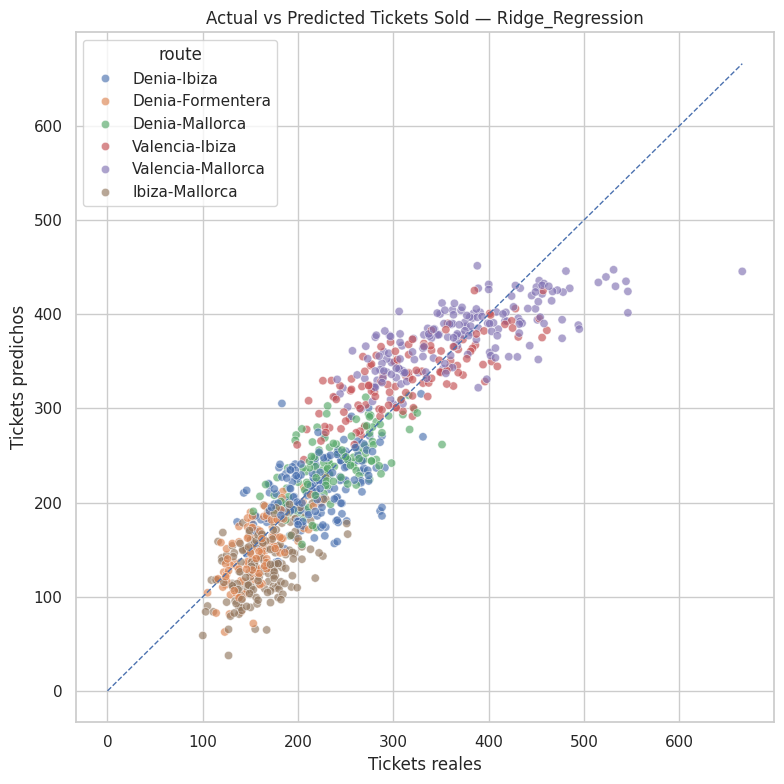

In [19]:
# ============================================================
# 19. GRÁFICO ACTUAL VS PREDICHO
# ============================================================

plt.figure(figsize=(8, 8))

sns.scatterplot(
    data=predictions_df,
    x="tickets_sold",
    y="predicted_tickets_sold",
    hue="route",
    alpha=0.65
)

max_value = max(
    predictions_df["tickets_sold"].max(),
    predictions_df["predicted_tickets_sold"].max()
)

plt.plot([0, max_value], [0, max_value], linestyle="--", linewidth=1)

plt.title(f"Actual vs Predicted Tickets Sold — {best_model_name}")
plt.xlabel("Tickets reales")
plt.ylabel("Tickets predichos")
plt.tight_layout()

plt.savefig(f"{images_path}/28_actual_vs_predicted_demand.png", dpi=300, bbox_inches="tight")

plt.show()

### 13.1 Visualización: actual vs predicho por ruta

Vamos a separar el gráfico anterior en gráficos individuales para cada ruta, lo que nos permitirá ver el rendimiento del modelo en cada una de ellas de forma más clara.

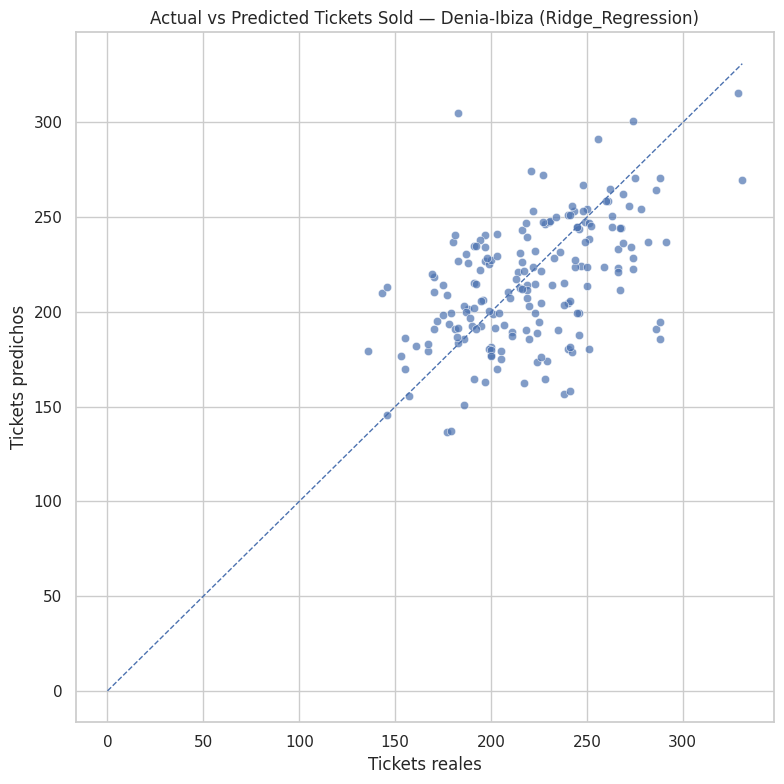

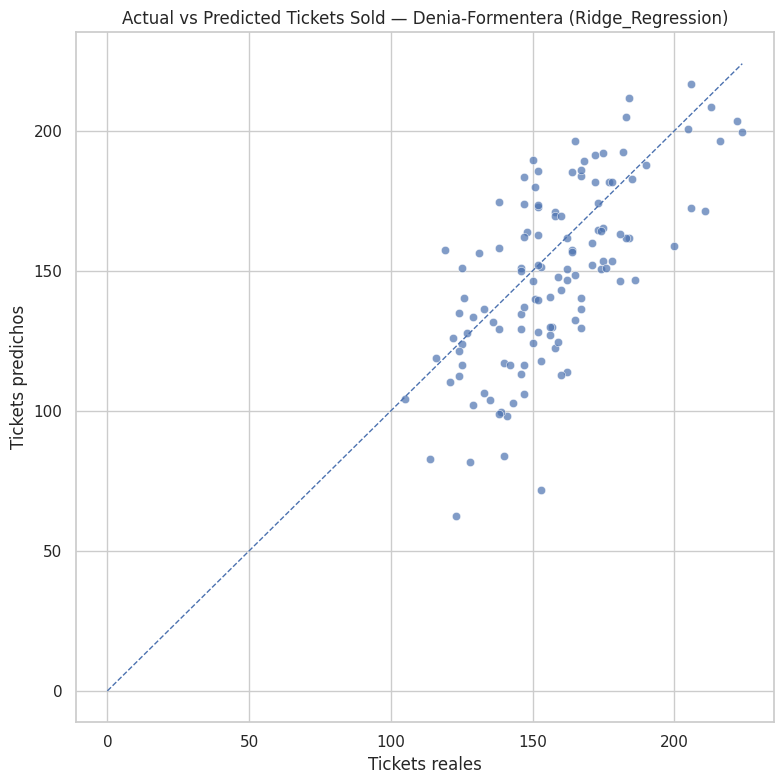

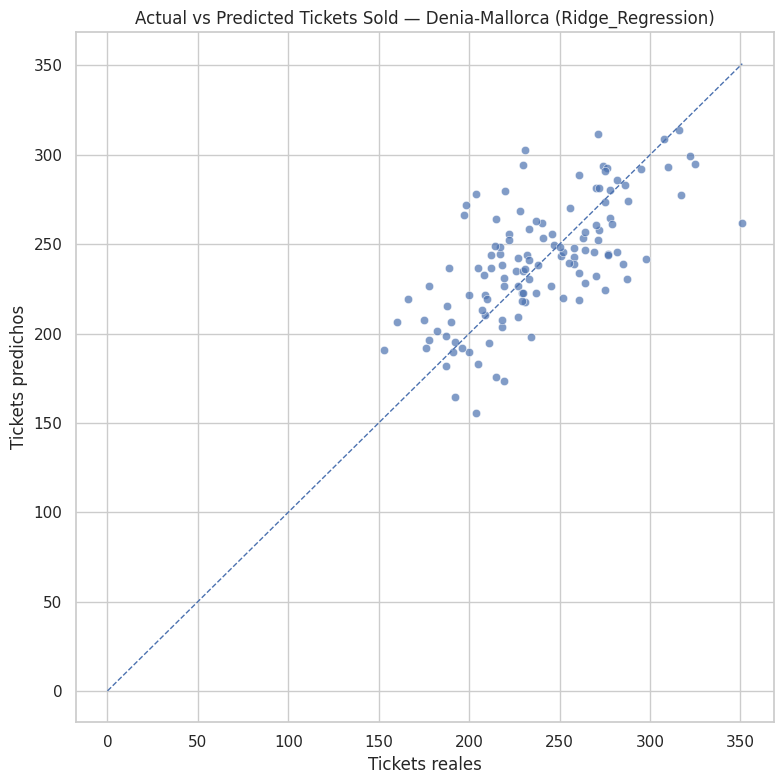

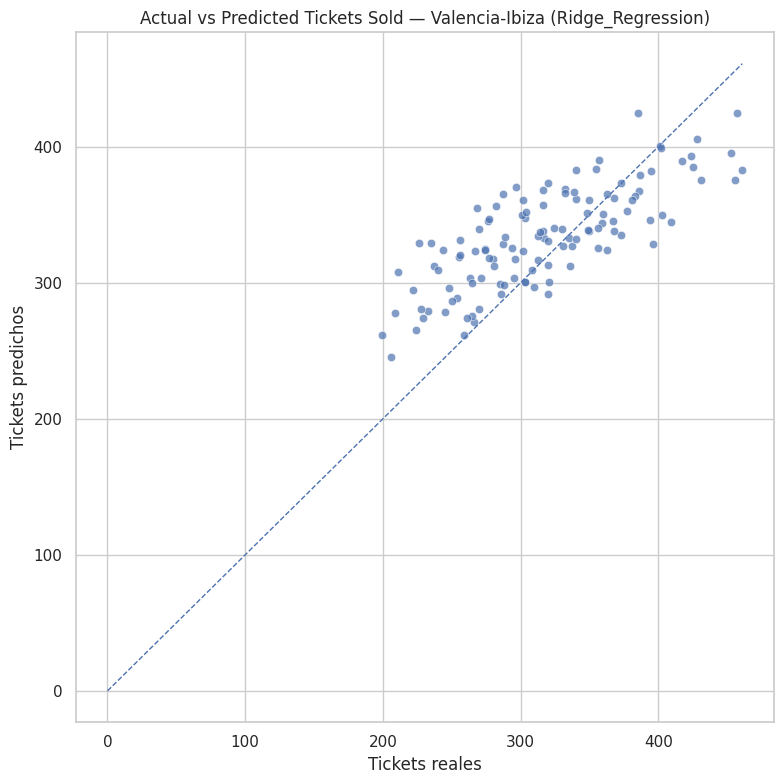

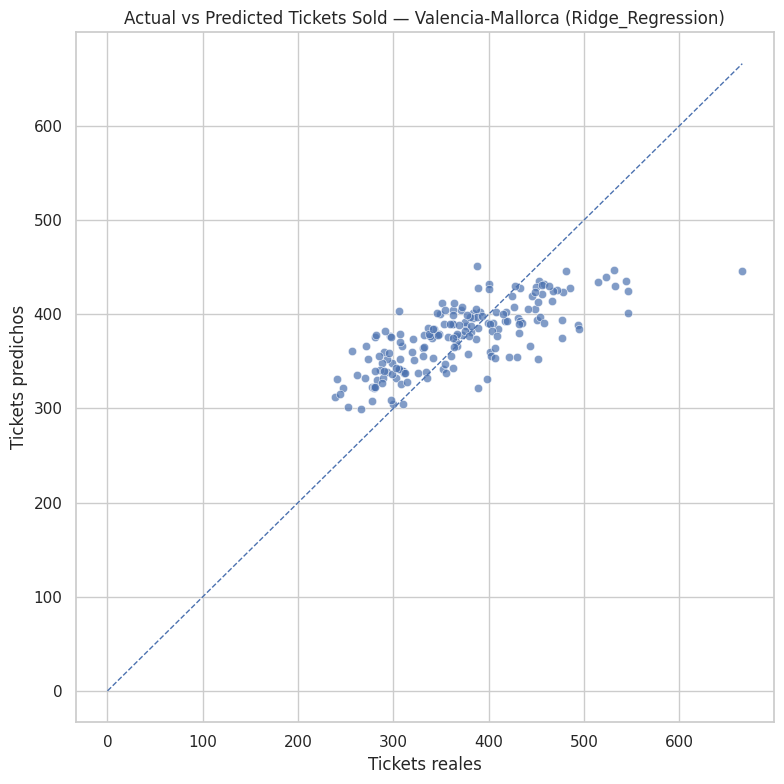

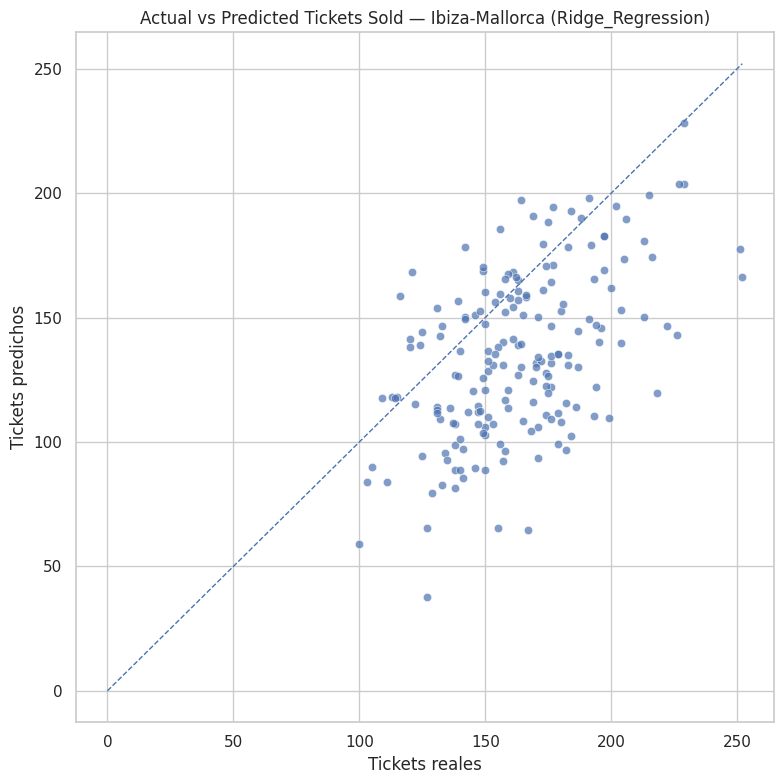

Gráficos de Actual vs Predicted Tickets Sold generados por ruta.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

unique_routes = predictions_df["route"].unique()

for route_name in unique_routes:
    route_df = predictions_df[predictions_df["route"] == route_name]

    plt.figure(figsize=(8, 8))

    sns.scatterplot(
        data=route_df,
        x="tickets_sold",
        y="predicted_tickets_sold",
        alpha=0.7
    )

    max_value = max(
        route_df["tickets_sold"].max(),
        route_df["predicted_tickets_sold"].max()
    )

    plt.plot([0, max_value], [0, max_value], linestyle="--", linewidth=1)

    plt.title(f"Actual vs Predicted Tickets Sold — {route_name} ({best_model_name})")
    plt.xlabel("Tickets reales")
    plt.ylabel("Tickets predichos")
    plt.tight_layout()

    # Save each plot with a unique filename based on the route
    safe_route_name = route_name.replace(" ", "_").replace("-", "_")
    plt.savefig(f"{images_path}/28_actual_vs_predicted_demand_{safe_route_name}.png", dpi=300, bbox_inches="tight")

    plt.show()

print("Gráficos de Actual vs Predicted Tickets Sold generados por ruta.")

## 14. Visualización: distribución del error

Analizamos cómo se distribuyen los errores.

Lo ideal es que la mayoría estén cerca de cero.

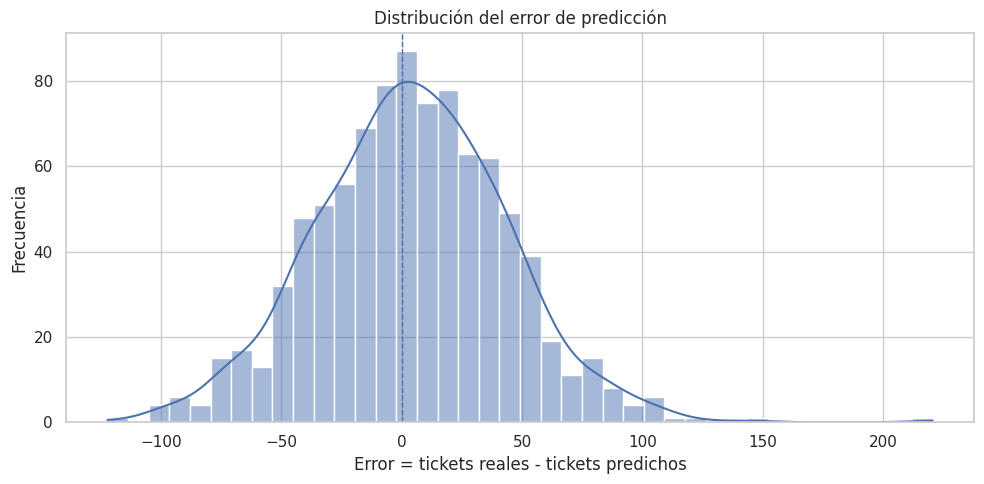

In [20]:
# ============================================================
# 20. DISTRIBUCIÓN DEL ERROR
# ============================================================

plt.figure(figsize=(10, 5))

sns.histplot(
    data=predictions_df,
    x="prediction_error",
    bins=40,
    kde=True
)

plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Distribución del error de predicción")
plt.xlabel("Error = tickets reales - tickets predichos")
plt.ylabel("Frecuencia")
plt.tight_layout()

plt.savefig(f"{images_path}/29_prediction_error_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## 15. Visualización: MAE por ruta

Este gráfico identifica dónde predice mejor o peor el modelo.

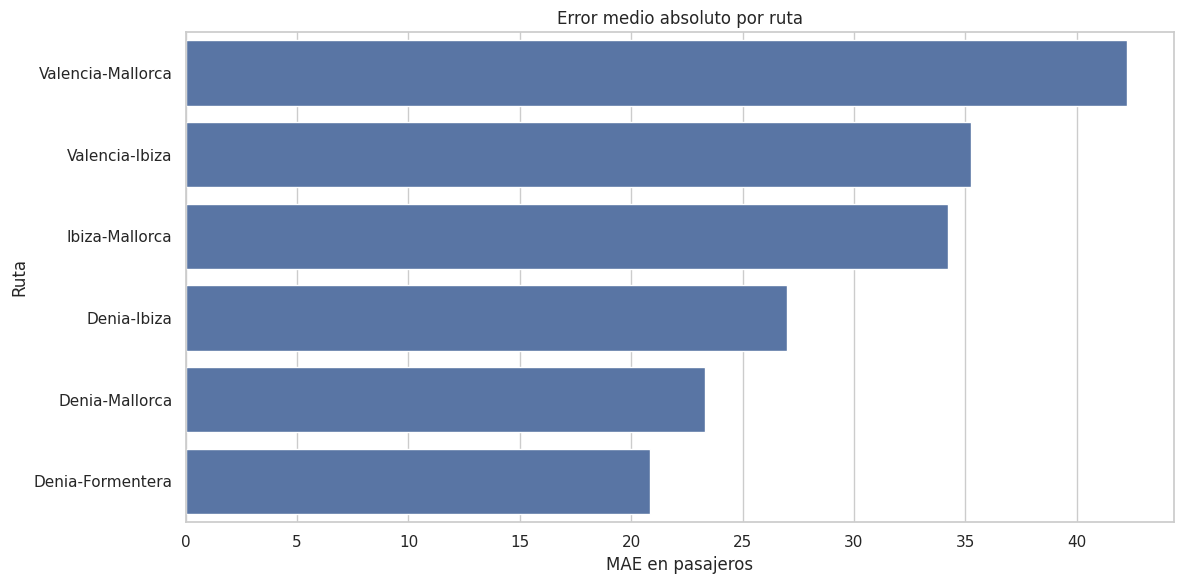

In [21]:
# ============================================================
# 21. MAE POR RUTA
# ============================================================

plt.figure(figsize=(12, 6))

plot_route_error = route_error_summary.sort_values("mae", ascending=False)

sns.barplot(
    data=plot_route_error,
    x="mae",
    y="route"
)

plt.title("Error medio absoluto por ruta")
plt.xlabel("MAE en pasajeros")
plt.ylabel("Ruta")
plt.tight_layout()

plt.savefig(f"{images_path}/30_mae_by_route.png", dpi=300, bbox_inches="tight")

plt.show()

## 16. Visualización temporal de predicciones

Comparamos demanda real y predicha agregada por fecha.

Esto ayuda a comprobar si el modelo sigue la tendencia general.

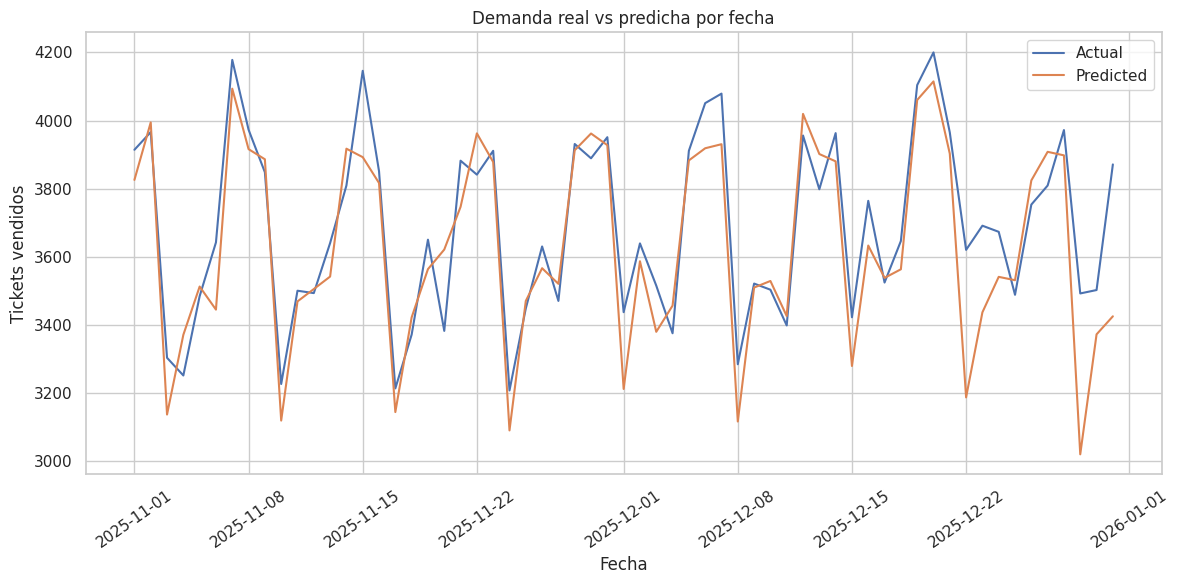

In [22]:
# ============================================================
# 22. SERIE TEMPORAL REAL VS PREDICHA
# ============================================================

daily_predictions = (
    predictions_df
    .groupby("trip_date")
    .agg(
        actual_tickets=("tickets_sold", "sum"),
        predicted_tickets=("predicted_tickets_sold", "sum")
    )
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=daily_predictions,
    x="trip_date",
    y="actual_tickets",
    label="Actual"
)

sns.lineplot(
    data=daily_predictions,
    x="trip_date",
    y="predicted_tickets",
    label="Predicted"
)

plt.title("Demanda real vs predicha por fecha")
plt.xlabel("Fecha")
plt.ylabel("Tickets vendidos")
plt.xticks(rotation=35)
plt.tight_layout()

plt.savefig(f"{images_path}/31_daily_actual_vs_predicted_demand.png", dpi=300, bbox_inches="tight")

plt.show()

## 17. Importancia de variables

Para modelos de árboles como Random Forest y Gradient Boosting podemos extraer importancia de variables.

Esto nos ayuda a responder:

¿Qué variables pesan más en la predicción de demanda?

In [23]:
# ============================================================
# 23. EXTRACCIÓN DE NOMBRES DE FEATURES TRANSFORMADAS
# ============================================================

def get_feature_names_from_preprocessor(fitted_pipeline):
    """
    Recupera nombres de variables después del preprocesamiento.
    """

    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]

    feature_names = []

    feature_names.extend(numeric_features)

    cat_pipeline = fitted_preprocessor.named_transformers_["cat"]
    onehot = cat_pipeline.named_steps["onehot"]
    cat_feature_names = onehot.get_feature_names_out(categorical_features)

    feature_names.extend(cat_feature_names)

    return feature_names


feature_names = get_feature_names_from_preprocessor(best_pipeline)

print(f"Número de variables transformadas: {len(feature_names)}")
feature_names[:20]

Número de variables transformadas: 45


['month',
 'week',
 'departure_hour',
 'is_weekend',
 'high_season_flag',
 'capacity',
 'base_price',
 'avg_ticket_price',
 'competitor_price',
 'price_index_vs_competitor',
 'route_elasticity',
 'days_before_departure',
 'weather_score',
 'event_flag',
 'route_Denia-Formentera',
 'route_Denia-Ibiza',
 'route_Denia-Mallorca',
 'route_Ibiza-Mallorca',
 'route_Valencia-Ibiza',
 'route_Valencia-Mallorca']

In [24]:
# ============================================================
# 24. FEATURE IMPORTANCE DEL MEJOR MODELO
# ============================================================

best_model = best_pipeline.named_steps["model"]

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values("importance", ascending=False)

else:
    feature_importance = pd.DataFrame({
        "feature": feature_names,
        "importance": np.nan
    })

    print("El mejor modelo no dispone de feature_importances_ directamente.")

feature_importance.head(20)

El mejor modelo no dispone de feature_importances_ directamente.


,feature,importance
0,month,NaN
1,week,NaN
2,departure_hour,NaN
3,is_weekend,NaN
4,high_season_flag,NaN
5,capacity,NaN
6,base_price,NaN
7,avg_ticket_price,NaN
8,competitor_price,NaN
9,price_index_vs_competitor,NaN


In [25]:
# ============================================================
# 25. GRÁFICO FEATURE IMPORTANCE
# ============================================================

if feature_importance["importance"].notna().any():

    top_features = feature_importance.head(20)

    plt.figure(figsize=(12, 7))

    sns.barplot(
        data=top_features,
        x="importance",
        y="feature"
    )

    plt.title(f"Top 20 variables más importantes — {best_model_name}")
    plt.xlabel("Importancia")
    plt.ylabel("Variable")
    plt.tight_layout()

    plt.savefig(f"{images_path}/32_feature_importance_demand_model.png", dpi=300, bbox_inches="tight")

    plt.show()
else:
    print("No se genera gráfico porque el modelo seleccionado no tiene feature_importances_.")

No se genera gráfico porque el modelo seleccionado no tiene feature_importances_.


## 18. Diagnóstico ejecutivo del modelo

Creamos una tabla final con las conclusiones del modelo por ruta.

Esta tabla será útil para el dashboard y para el README del proyecto.

In [26]:
# ============================================================
# 26. DIAGNÓSTICO EJECUTIVO POR RUTA
# ============================================================

def model_route_diagnosis(row):
    if row["mae"] <= 15 and row["mape"] <= 0.08:
        return "High reliability"
    elif row["mae"] <= 30 and row["mape"] <= 0.15:
        return "Good reliability"
    elif row["mae"] <= 50:
        return "Moderate reliability"
    else:
        return "Needs review"


route_model_diagnosis = route_error_summary.copy()
route_model_diagnosis["model_reliability"] = route_model_diagnosis.apply(model_route_diagnosis, axis=1)

route_model_diagnosis = route_model_diagnosis[[
    "route",
    "trips",
    "actual_tickets",
    "predicted_tickets",
    "mae",
    "rmse",
    "mape",
    "avg_actual_occupancy",
    "avg_predicted_occupancy",
    "total_revenue",
    "avg_margin_pct",
    "model_reliability"
]].sort_values("mae")

route_model_diagnosis

,route,trips,actual_tickets,predicted_tickets,mae,rmse,mape,avg_actual_occupancy,avg_predicted_occupancy,total_revenue,avg_margin_pct,model_reliability
0,Denia-Formentera,122,19197,"18,088.6008",20.8488,25.4026,0.1355,0.5620,0.5295,"1,306,864.8700",-0.3681,Good reliability
2,Denia-Mallorca,122,29105,"29,378.1409",23.3090,29.8527,0.1018,0.4588,0.4631,"1,716,482.9800",-0.8208,Good reliability
1,Denia-Ibiza,183,40270,"39,410.0111",27.0110,34.6453,0.1253,0.6287,0.6153,"2,186,930.3900",-0.4035,Good reliability
3,Ibiza-Mallorca,183,29843,"24,653.5809",34.2156,41.6902,0.2089,0.5436,0.4491,"1,354,071.8500",-0.7948,Moderate reliability
4,Valencia-Ibiza,122,38681,"40,763.9513",35.2813,43.2624,0.1218,0.5114,0.5389,"2,469,757.8500",-0.4828,Moderate reliability
5,Valencia-Mallorca,183,67830,"68,904.6291",42.2609,52.5862,0.1181,0.5295,0.5379,"3,893,343.4000",-0.5480,Moderate reliability


## 19. Guardado del modelo

Guardamos el mejor pipeline completo.

Esto incluye:

- Preprocesamiento.
- One Hot Encoding.
- Escalado.
- Modelo entrenado.

Así podremos reutilizarlo posteriormente sin reconstruirlo desde cero.

In [27]:
# ============================================================
# 27. GUARDADO DEL MODELO
# ============================================================

model_output_path = f"{models_path}/demand_prediction_model_{best_model_name}.joblib"

joblib.dump(best_pipeline, model_output_path)

print("Modelo guardado correctamente en:")
print(model_output_path)

Modelo guardado correctamente en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/models/demand_prediction_model_Ridge_Regression.joblib


## 20. Guardado de resultados

Exportamos las tablas principales en:

- CSV estándar.
- CSV compatible con Excel España.
- XLSX.

In [28]:
# ============================================================
# 28. GUARDADO DE TABLAS
# ============================================================

tables_to_export = {
    "demand_model_leaderboard": model_leaderboard,
    "demand_model_predictions_test": predictions_df,
    "demand_model_route_error_summary": route_error_summary,
    "demand_model_season_error_summary": season_error_summary,
    "demand_model_daily_predictions": daily_predictions,
    "demand_model_feature_importance": feature_importance,
    "demand_model_route_diagnosis": route_model_diagnosis
}

for file_name, table in tables_to_export.items():
    export_table_files(
        dataframe=table,
        output_folder=reports_path,
        file_name=file_name,
        sheet_name=file_name[:31]
    )

print("Tablas del modelo de demanda exportadas correctamente.")

Exportado: demand_model_leaderboard
Exportado: demand_model_predictions_test
Exportado: demand_model_route_error_summary
Exportado: demand_model_season_error_summary
Exportado: demand_model_daily_predictions
Exportado: demand_model_feature_importance
Exportado: demand_model_route_diagnosis
Tablas del modelo de demanda exportadas correctamente.


## 21. Resumen ejecutivo en Markdown

Creamos un resumen ejecutivo automático del notebook.

In [29]:
# ============================================================
# 29. RESUMEN EJECUTIVO EN MARKDOWN
# ============================================================

best_route = route_model_diagnosis.sort_values("mae").iloc[0]
worst_route = route_model_diagnosis.sort_values("mae", ascending=False).iloc[0]

executive_summary = f"""
# Executive Summary — Demand Prediction Model

## Project context

This notebook builds a supervised Machine Learning model to predict passenger demand for a simulated ferry operator: Levante Ferries.

The target variable is `tickets_sold`.

## Best model

- Selected model: {best_model_name}
- MAE: {best_model_metrics['mae']:.2f} passengers
- RMSE: {best_model_metrics['rmse']:.2f} passengers
- R²: {best_model_metrics['r2']:.3f}
- MAPE: {best_model_metrics['mape']:.2%}

## Route-level findings

- Best predicted route: {best_route['route']} with MAE {best_route['mae']:.2f}
- Most difficult route to predict: {worst_route['route']} with MAE {worst_route['mae']:.2f}

## Business interpretation

The model can be used to estimate expected demand before making pricing decisions.
This allows the revenue team to identify trips with potential under-occupancy, saturation risk or pricing opportunities.

The model should not be used as an automatic pricing engine.
It should be used as a decision-support tool combined with:

- Price elasticity.
- Occupancy.
- Margin.
- Competitive price index.
- Operational constraints.

## Next step

The next notebook will use demand prediction and pricing logic to build a scenario simulator and pricing recommendation engine.
"""

summary_path = f"{reports_path}/executive_summary_notebook_04.md"

with open(summary_path, "w", encoding="utf-8") as file:
    file.write(executive_summary)

print("Resumen ejecutivo guardado en:")
print(summary_path)

Resumen ejecutivo guardado en:
/content/drive/MyDrive/7 Colab Notebooks/1 Porfolio/Balearia/3 Pricing/reports/executive_summary_notebook_04.md


In [30]:
# ============================================================
# 30. ARCHIVOS GENERADOS
# ============================================================

print("Imágenes generadas en el Notebook 4:")
for file in sorted(os.listdir(images_path)):
    if file.endswith(".png") and file.startswith(("28_", "29_", "30_", "31_", "32_")):
        print("-", file)

print("\nReportes generados en el Notebook 4:")
for file in sorted(os.listdir(reports_path)):
    if (
        file.startswith("demand_model_") or
        file == "executive_summary_notebook_04.md"
    ):
        print("-", file)

print("\nModelos guardados:")
for file in sorted(os.listdir(models_path)):
    if file.endswith(".joblib"):
        print("-", file)

Imágenes generadas en el Notebook 4:
- 28_actual_vs_predicted_demand.png
- 29_prediction_error_distribution.png
- 30_mae_by_route.png
- 31_daily_actual_vs_predicted_demand.png

Reportes generados en el Notebook 4:
- demand_model_daily_predictions.csv
- demand_model_daily_predictions.xlsx
- demand_model_daily_predictions_excel_es.csv
- demand_model_feature_importance.csv
- demand_model_feature_importance.xlsx
- demand_model_feature_importance_excel_es.csv
- demand_model_leaderboard.csv
- demand_model_leaderboard.xlsx
- demand_model_leaderboard_excel_es.csv
- demand_model_predictions_test.csv
- demand_model_predictions_test.xlsx
- demand_model_predictions_test_excel_es.csv
- demand_model_route_diagnosis.csv
- demand_model_route_diagnosis.xlsx
- demand_model_route_diagnosis_excel_es.csv
- demand_model_route_error_summary.csv
- demand_model_route_error_summary.xlsx
- demand_model_route_error_summary_excel_es.csv
- demand_model_season_error_summary.csv
- demand_model_season_error_summary.xl

## Conclusiones del Notebook 4

En este notebook se ha construido un modelo predictivo de demanda para estimar `tickets_sold` en rutas de ferry.

El análisis ha incluido:

- Selección de variables predictoras sin fuga de información.
- División temporal train/test.
- Preprocesamiento de variables numéricas y categóricas.
- Entrenamiento de varios modelos.
- Comparación mediante MAE, RMSE, R² y MAPE.
- Selección del mejor modelo.
- Análisis de errores por ruta y temporada.
- Visualización de predicciones.
- Interpretabilidad mediante importancia de variables.
- Exportación de tablas, gráficos y modelo entrenado.

La principal conclusión es que el modelo de demanda puede utilizarse como herramienta de apoyo a decisiones de pricing, especialmente cuando se combina con elasticidad, ocupación, margen y posición frente a competidores.

Este notebook prepara la base para el siguiente paso: construir un simulador y recomendador de pricing.